# 시계열 데이터 AR/MA/ARIMA 분석 실전 워크플로우
## 1. 가상의 시계열 데이터 생성

- ArmaProcess로 AR/MA 계수를 임의로 설정, 임의의 시계열 데이터 생성
- np.cumsum을 적용해 차분(비정상성) 효과를 만들어 실제 경제 데이터처럼 보이게 만듬

In [173]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess
import koreanize_matplotlib
import warnings
import seaborn as sns

warnings.filterwarnings('ignore')

np.random.seed(42)
n = 200

# ARIMA(1,1,1)에 기반한 시계열 데이터 생성
ar = np.array([1, -0.7])        # AR(1) 계수
ma = np.array([1, 0.5])         # MA(1) 계수
arma_process = ArmaProcess(ar, ma)
base_data = arma_process.generate_sample(nsample=n)
ts = np.cumsum(base_data)       # 1차 차분이 적용된 데이터, 정상성이 큼

# DataFrame화
df = pd.DataFrame({'y': ts})
df.index = pd.date_range(start='2020-01-01', periods=n)
df.head()

,y
2020-01-01,0.496714
2020-01-02,0.954507
2020-01-03,1.853518
2020-01-04,4.329700
2020-01-05,6.590389


## 2. 결측치/이상치 추가 및 전처리

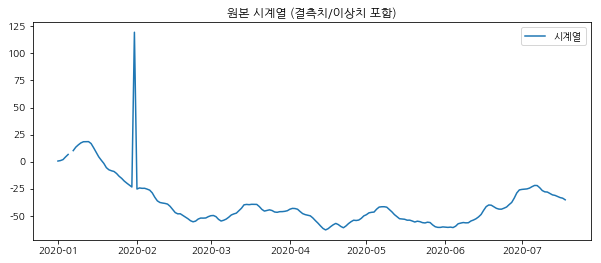

In [174]:
# 결측치와 이상치 삽입
df.iloc[5, 0] = np.nan
df.iloc[30, 0] = df['y'].mean() + 8*df['y'].std()        # 이상치

plt.figure(figsize=(10,4))
plt.plot(df['y'], label='시계열')
plt.title('원본 시계열 (결측치/이상치 포함)')
plt.legend()
plt.show()

### 결측치 처리

시계열 데이터는 시간의 흐름을 반영하므로, 임의 결측치는 선형 보간 등 인접한 값들의 추세로 대체

In [175]:
# 1. 시계열에서는 보간법(interpolation) 추천
df['y'] = df['y'].interpolate(method='linear')

### 이상치 처리

z-score로 표준화된 값 중 ±3 이상에 해당하면 이상치로 판단, 중위수로 대체하는 것이 일반적이며 예측 성능이 흔들리는 것을 방지

In [176]:
from scipy.stats import zscore
z = np.abs(zscore(df['y']))
df.loc[z > 3, 'y'] = np.median(df['y'])   # z-score 3 초과를 중위수로 대체(잔차 분산이 튄다... 삭제하고 보간해보자)

# 아예 삭제 후 보간한다면
df['y2'] = df['y']
df.loc[z > 3, 'y2']  = np.nan
df['y2'] = df['y2'].interpolate(method='linear')

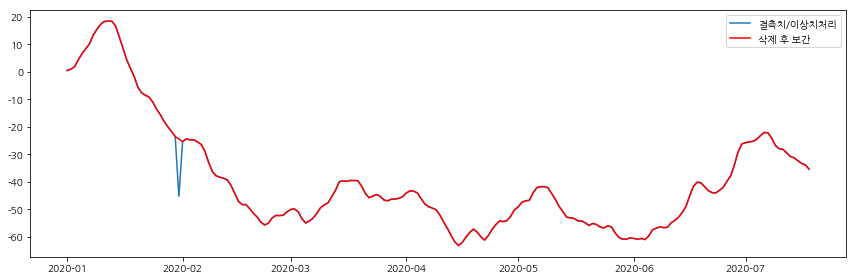

In [177]:
fig, ax = plt.subplots(1, 1, figsize=(12,4))
sns.lineplot(data=df['y'], label='결측치/이상치처리', ax=ax)
sns.lineplot(data=df['y2'], label='삭제 후 보간', ax=ax, color='r')
plt.legend()
plt.tight_layout()
plt.show()

## 3. 시계열 분해와 정상성 확보(차분)

시계열 분해로 추세, 계절성, 불규칙성 여부를 시각적으로 확인

### 정상성(Stationarity) 검정 및 차분

Augmented Dickey-Fuller(ADF) 검정으로 정상성 확인, p-value > 0.05면 차분(differencing)이 필요
- H0: 단위근이 있다.(정상성이 없다.)
- H1: 단위근이 없다.(정상성이 있다.)

kpss 검정도 가능

In [178]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(y):
    result = adfuller(y)
    print(f'ADF 통계량: {result[0]:.4f}, p-value: {result[1]:.4f}')
    if result[1] < 0.05:
        print('→ 정상성 만족')
    else:
        print('→ 정상성 없음, 차분 필요')

check_stationarity(df['y'])

# 만약 정상성 만족이 되지 않으면
df['y_diff'] = df['y'].diff(1).dropna()
check_stationarity(df['y_diff'].dropna())

ADF 통계량: -1.9843, p-value: 0.2935
→ 정상성 없음, 차분 필요
ADF 통계량: -6.0460, p-value: 0.0000
→ 정상성 만족


## 4. ACF/PACF로 AR(p), MA(q) 결정

- 반드시 정상성 만족 후 진행 필요

- ACF: MA(q) 계수 결정(q=최초로 신뢰구간 안에 들어가는 lag)
- PACF: AR(p) 계수 결정(p=최초로 신뢰구간 안에 들어가는 lag)

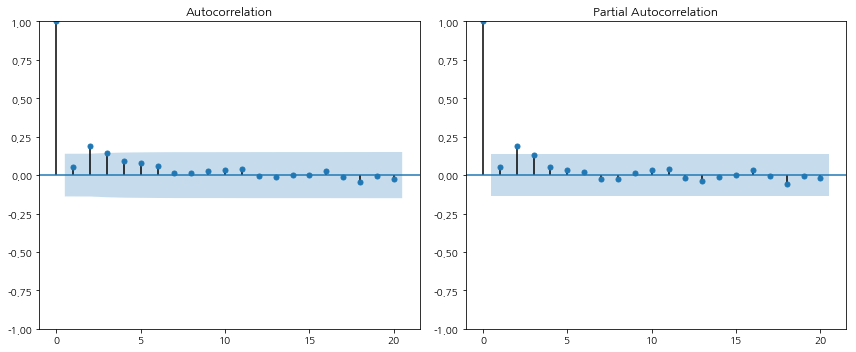

In [179]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plot_acf(df['y_diff'].dropna(), lags=20, ax=ax[0])
plot_pacf(df['y_diff'].dropna(), lags=20, ax=ax[1])
plt.tight_layout()
plt.show()

- p: PACF 에서 lag4부터 최초로 신뢰구간 안에 들어가므로 3(하지만 애매하게 걸쳐있어서 2)
- q: ACF에서 lag4부터 신뢰구간 안에 완전히 들어가므로 3(하지만 애매하게 걸쳐있어서 2)
- d: 차분을 1번 수행하여 정상성을 만족했으므로 1



- 신뢰구간을 벗어난 지점들: lag 1, 2, 3
- 신뢰구간 안으로 들어온 지점: lag 4부터
  → p 또는 q = 3 (신뢰구간을 벗어난 마지막 lag)



- 통계적 유의성: 신뢰구간을 벗어난다는 것은 통계적으로 유의하다는 의미
- 절단점의 정의: 유의한 값이 마지막으로 나타나는 지점이 모델 차수
- 실무적 접근: 신뢰구간 안으로 들어간 첫 번째 지점이 아니라, 유의한 마지막 지점을 사용

## 5. AR, MA, ARIMA 모델 적합 및 평가

1. AR: AR (Autoregressive) Model: 현재 시점의 값이 과거 자신의 값들의 선형결합으로 표현되는 모델
    - **수학적 표현**: 
      $$X_t = c + \phi_1 X_{t-1} + \phi_2 X_{t-2} + \cdots + \phi_p X_{t-p} + \varepsilon_t$$
        - **p**: AR 모델의 차수 (order)
        - **φ₁, φ₂, ..., φₚ**: 자기회귀 계수 (autoregressive parameters)
        - **εₜ**: 백색잡음 (white noise) 오차항

2. **MA (Moving Average) Model**: 현재 시점의 값이 현재와 과거의 오차항들의 선형결합으로 표현되는 모델
    - **수학적 표현**:
      $$X_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \cdots + \theta_q \varepsilon_{t-q}$$
        - **q**: MA 모델의 차수
        - **θ₁, θ₂, ..., θₑ**: 이동평균 계수 (moving average parameters)
        - **μ**: 시계열의 평균

3. **ARIMA (Autoregressive Integrated Moving Average) Model**: 비정상 시계열을 차분을 통해 정상화한 후 ARMA 모델을 적용하는 확장 모델
    - **표기법**: ARIMA(p,d,q)
        - **p**: 자기회귀 차수
        - **d**: 차분 차수 (degree of differencing)
        - **q**: 이동평균 차수

4. 주요이론
  - **Stationarity (정상성)**: 시계열의 통계적 성질(평균, 분산, 자기공분산)이 시간에 따라 변하지 않는 특성
    - **강정상성 (Strict Stationarity)**: 모든 차수의 결합분포가 시간이동에 불변
    - **약정상성 (Weak Stationarity)**: 평균, 분산, 자기공분산만 시간불변
  -  **Unit Root (단위근)**: AR 특성방정식의 근이 1인 경우로, 비정상성의 원인이 되는 근
  -  **Differencing (차분)**: 연속된 관측값의 차이를 구하여 추세를 제거하고 정상성을 달성하는 변환
     $$\nabla X_t = X_t - X_{t-1}$$

5. 진단 및 분석도구
  - **ACF (Autocorrelation Function)**: 시계열과 자신의 지연된 값들 간의 상관계수를 lag별로 나타낸 함수
    **수학적 표현**:
    $$\rho_k = \frac{\text{Cov}(X_t, X_{t-k})}{\sqrt{\text{Var}(X_t) \cdot \text{Var}(X_{t-k})}}$$
    **이론적 특성**:
    - **AR(p)**: 점진적으로 감소 (tail off)
    - **MA(q)**: q 이후 절단 (cut off)
    - **ARMA(p,q)**: 점진적으로 감소
  - **PACF (Partial Autocorrelation Function)**: 중간 시차들의 영향을 제거한 후 특정 lag에서의 순수한 상관관계
    **특성**:
    - **AR(p)**: p 이후 절단
    - **MA(q)**: 점진적으로 감소
    - **ARMA(p,q)**: 점진적으로 감소
    
6. 모델선택기준
  - AIC : 모델의 적합도와 복잡도의 균형을 고려한 정보이론 기반 모델 선택 기준
    **공식**: 
    $$AIC = -2\ln(\hat{L}) + 2k$$
    - **L̂**: 최대우도값
    - **k**: 모델 파라미터 개수
  - **BIC (Bayesian Information Criterion)**: 베이지안 관점에서 모델 복잡도에 더 큰 페널티를 부과하는 선택 기준
    **공식**:
    $$BIC = -2\ln(\hat{L}) + k\ln(n)$$
    - **n**: 표본 크기
  - 그 밖의 성능지표: MSE, RMSE, MAE, MAPE 등

7. 통계적 검정
  -  **ADF Test (Augmented Dickey-Fuller Test)**: 단위근 존재 여부를 통한 정상성 검정
    - **귀무가설**: 단위근 존재 (비정상)
    - **대립가설**: 정상시계열
  - **Ljung-Box Test**: 잔차의 자기상관 검정
    - **귀무가설**: 자기상관 없음
    - **대립가설**: 자기상관 존재
  - **Jarque-Bera Test**: 잔차의 정규성 검정
    - **귀무가설**: 정규분포를 따름
    - **대립가설**: 정규분포를 따르지 않음
   - **Heteroskedasticity Test**: 등분산성 검정
      - **귀무가설**: 잔차(오차항)의 분산이 일정함
      - **대립가설**: 잔차(오차항)의 분산이 일정하지 않다

In [180]:
# AR 모델: q(2)
from statsmodels.tsa.ar_model import AutoReg

ar_model = AutoReg(df['y_diff'].dropna(), lags=2).fit()
print(ar_model.summary())

                            AutoReg Model Results                             
Dep. Variable:                 y_diff   No. Observations:                  199
Model:                     AutoReg(2)   Log Likelihood                -470.551
Method:               Conditional MLE   S.D. of innovations              2.637
Date:                Sun, 31 Aug 2025   AIC                            949.102
Time:                        20:49:09   BIC                            962.235
Sample:                    01-04-2020   HQIC                           954.418
                         - 07-18-2020                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1496      0.189     -0.793      0.428      -0.519       0.220
y_diff.L1      0.0419      0.070      0.598      0.550      -0.095       0.179
y_diff.L2      0.1859      0.070      2.655      0.0

AR(2) 모델 학습 결과이다.

Log Likelihood 값은 수치가 높을수록 모형 적합도가 높아짐

AIC(낮을수록 좋음)
BIC(낮을수록 좋음, 모델 단순성까지 고려)

모수추정결과: 모든 항목이 유의확률 5% 하에서 통계적으로 유의한지 확인  
ar(1) ~ (3) 계수

In [181]:
# MA 모델: p(2)

from statsmodels.tsa.arima.model import ARIMA

#차분 수행 전 데이터 넣음: d=1 설정했기 때문
ma_model = ARIMA(df['y'], order=(0,1,2)).fit()
print(ma_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:                 ARIMA(0, 1, 2)   Log Likelihood                -475.424
Date:                Sun, 31 Aug 2025   AIC                            956.848
Time:                        20:49:12   BIC                            966.728
Sample:                    01-01-2020   HQIC                           960.847
                         - 07-18-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.0093      0.020      0.479      0.632      -0.029       0.048
ma.L2          0.1658      0.053      3.100      0.002       0.061       0.271
sigma2         6.9585      0.196     35.573      0.0

잔차진단: 정규성, 등분산성 불만족

- Ljung-Box: p-value 0.81로 잔차에 자기상관 없음: 독립성 만족
- Jarque-Bera (JB): p-value 0.0로 잔차가 정규분포를 따르지 않음
- Heteroskedasticity (H): p-value 0.0로 잔차의 분산이 일정하지 않음

In [184]:
# ARIMA 모델: p(2), d(1), q(2)

arima_model = ARIMA(df['y'], order=(3,1,3)).fit()
print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:                 ARIMA(3, 1, 3)   Log Likelihood                -472.479
Date:                Sun, 31 Aug 2025   AIC                            958.959
Time:                        20:50:09   BIC                            982.012
Sample:                    01-01-2020   HQIC                           968.289
                         - 07-18-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6154     61.200      0.010      0.992    -119.334     120.565
ar.L2          0.0835     47.083      0.002      0.999     -92.198      92.365
ar.L3          0.0078      1.667      0.005      0.9

모수추정결과: ma.L1를 제외한 모든 항목이 유의확률 5% 하에서 통계적으로 유의

- ar.L1:  AR(1) 계수
- ar.L2: AR(2) 계수
- ma.L1: MA(1) 계수
- ma.L2: MA(2) 계수
-  sigma2: 오차의 분산(낮을수록 예측이 정밀함)


잔차진단: 정규성, 등분산성 불만족

- Ljung-Box: p-value 0.98 로 잔차에 자기상관 없음
- Jarque-Bera (JB): p-value 0.0로 잔차가 정규분포를 따르지 않음
- Heteroskedasticity (H): p-value 0로 잔차의 분산이 일정하지 않음

### 모델 예측 및 시각화

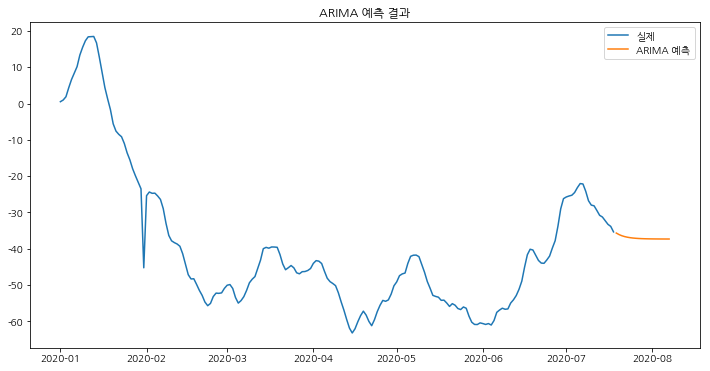

In [185]:
plt.figure(figsize=(12, 6))
forecast = arima_model.forecast(steps=20)
plt.plot(df['y'], label='실제')
plt.plot(forecast.index, forecast, label='ARIMA 예측')
plt.legend()
plt.title('ARIMA 예측 결과')
plt.show()

## 6. 모델 성능 평가

,model_name,AIC,BIC,mae,mse,rmse
0,AR(2),779.507656,791.732639,36.342033,1428.351585,37.793539
1,MA(2),787.738961,796.945674,19.576312,489.234369,22.118643
2,"ARIMA(3, 1, 3)",790.969539,812.451869,17.970260,422.481184,20.554347
3,"ARIMA(0, 1, 0)",787.818191,797.024903,18.421861,438.329008,20.936308


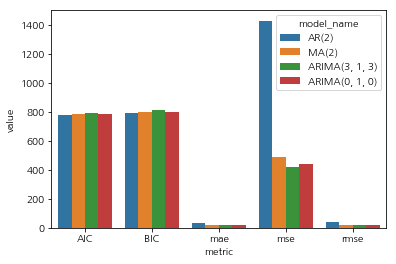

In [187]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 실제값(테스트 구간) vs 예측값
split = int(len(df) * 0.8)
train, test = df['y'].iloc[:split], df['y'].iloc[split:]

rs = pd.DataFrame(columns=['model_name', 'AIC', 'BIC', 'mae', 'mse', 'rmse'])

model_name = ['AR(2)', 'MA(2)', 'ARIMA(3, 1, 3)', 'ARIMA(0, 1, 0)']
model_list = [AutoReg(train.diff(1).dropna(), lags=2).fit(), ARIMA(train, order=(0,1,2)).fit(), ARIMA(train, order=(3,1,3)).fit(), ARIMA(train, order=(1,1,1)).fit()]

for name, model in zip(model_name, model_list):
    pred = model.forecast(steps=len(test))
    aic = model.aic
    bic = model.bic
    mae = mean_absolute_error(test, pred)
    mse = mean_squared_error(test, pred)
    rmse = np.sqrt(mse)
    rs.loc[len(rs)] = [name, aic, bic, mae, mse, rmse]

display(rs)

rs = rs.melt(id_vars='model_name', var_name='metric', value_name='value')

import seaborn as sns

sns.barplot(data=rs, x='metric', y='value', hue='model_name')
plt.show()

최적 모델: ARIMA(3,1,3)

선정 근거:
1. 예측 정확도: MAE(17.98), RMSE(20.56) 모두 최우수
2. AIC(786.97): AR(2) 다음으로 낮음
3. 실무에서는 예측 성능이 모델 선택의 핵심 기준
4. 약간의 복잡도 증가 대비 성능 향상이 뚜렷함

결론: ARIMA(2,1,2) 모델을 최종 선택

MAE: 17.970
RMSE: 20.554


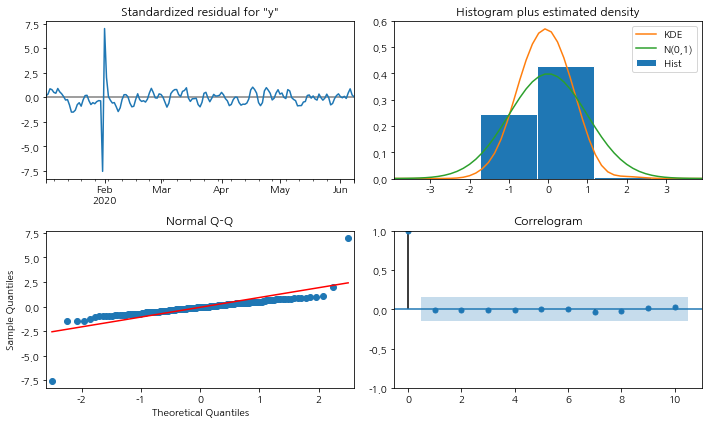

In [188]:
model = ARIMA(train, order=(3,1,3)).fit()

forecast = model.get_forecast(steps=len(test))
f_mean = forecast.predicted_mean
MAE = mean_absolute_error(test, f_mean)
rmse = np.sqrt(mean_squared_error(test, f_mean))
print(f"MAE: {MAE:.3f}")
print(f"RMSE: {rmse:.3f}")
model.plot_diagnostics(figsize=(10, 6)) #잔차 그래프
plt.tight_layout()
plt.show()

| 순서  | 그래프 이름                                  | 확인할 것               | 의미                                                |
| --- | --------------------------------------- | ------------------- | ------------------------------------------------- |
| 1️⃣ | **Standardized residuals** (표준화 잔차 시계열) | 잔차가 일정한 분포를 보이는가?   | **평균이 0, 분산이 일정**해야 함 → 시계열성이 없어야 함               |
| 2️⃣ | **Histogram plus KDE**                  | 잔차가 정규분포를 따르는가?     | **종 모양** 여부 확인 → 정규성 가정 충족 여부                     |
| 3️⃣ | **Normal Q-Q plot**                     | 잔차가 정규분포와 얼마나 가까운가? | 점이 대각선 근처에 있으면 정규분포와 유사                           |
| 4️⃣ | **Correlogram (ACF plot of residuals)** | 잔차에 자기상관이 남아 있는가?   | lag별 자기상관 확인 → **신뢰구간 내**면 "white noise(백색잡음)"로 봄 |


In [189]:
from pmdarima import auto_arima

new_model = auto_arima(train, seasonal=False, stepwise=True)
print(new_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  160
Model:               SARIMAX(0, 1, 0)   Log Likelihood                -391.534
Date:                Sun, 31 Aug 2025   AIC                            787.069
Time:                        20:52:11   BIC                            793.207
Sample:                    01-01-2020   HQIC                           789.561
                         - 06-08-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.3575      0.226     -1.583      0.113      -0.800       0.085
sigma2         8.0614      0.215     37.554      0.000       7.641       8.482
Ljung-Box (L1) (Q):                   0.21   Jarque-

# 삭제 후 보간 데이터로 다시 확인

In [190]:
check_stationarity(df['y2'])

ADF 통계량: -3.0276, p-value: 0.0324
→ 정상성 만족


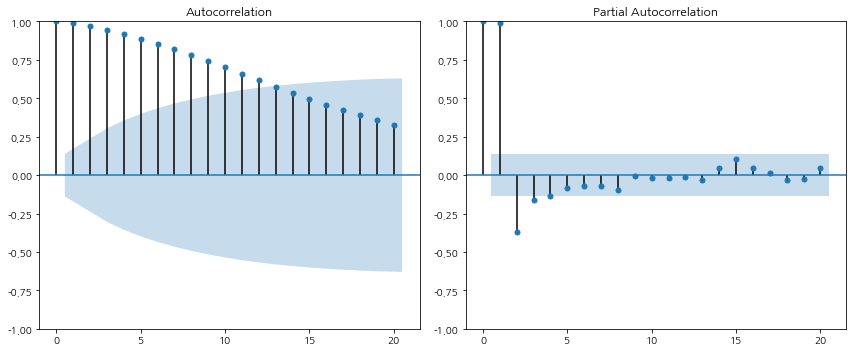

In [191]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plot_acf(df['y2'].dropna(), lags=20, ax=ax[0])
plot_pacf(df['y2'].dropna(), lags=20, ax=ax[1])
plt.tight_layout()
plt.show()

ACF 는 천천히 감소하고, PCAF에서 lag 4부터 신뢰구간에서 들어가므로 AR(4)

In [192]:
ar2 = ARIMA(df['y2'], order=(4,0,0)).fit() #사실상 ar임
print(ar2.summary())

                               SARIMAX Results                                
Dep. Variable:                     y2   No. Observations:                  200
Model:                 ARIMA(4, 0, 0)   Log Likelihood                -274.914
Date:                Sun, 31 Aug 2025   AIC                            561.828
Time:                        20:53:44   BIC                            581.618
Sample:                    01-01-2020   HQIC                           569.837
                         - 07-18-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        -33.4542     10.197     -3.281      0.001     -53.439     -13.469
ar.L1          2.0836      0.081     25.742      0.000       1.925       2.242
ar.L2         -1.5294      0.179     -8.542      0.0

MAE: 8.427
RMSE: 10.074


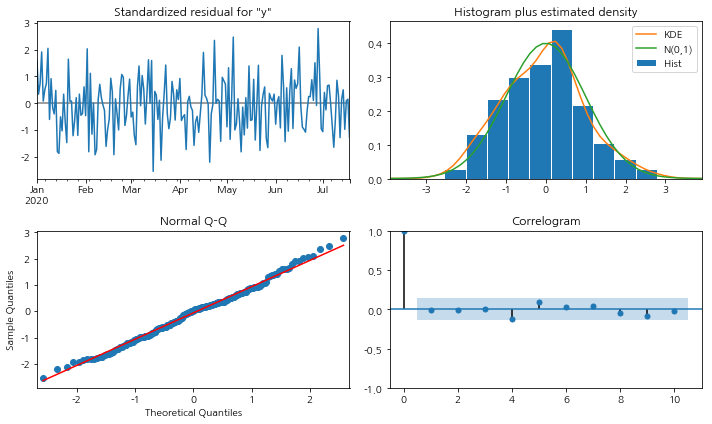

In [193]:
split = int(len(df) * 0.8)
train, test = df['y2'].iloc[:split], df['y2'].iloc[split:]

forecast = ar2.get_forecast(steps=len(test))
f_mean = forecast.predicted_mean
MAE = mean_absolute_error(test, f_mean)
rmse = np.sqrt(mean_squared_error(test, f_mean))
print(f"MAE: {MAE:.3f}")
print(f"RMSE: {rmse:.3f}")
ar2.plot_diagnostics(figsize=(10, 6)) #잔차 그래프
plt.tight_layout()
plt.show()

In [197]:
dates = pd.date_range('2010-01', periods=82, freq='M')
np.random.seed(42)

# 원래 신호에 선형 증가하는 추세 추가 (예: 월별 0.5씩 증가)
trend = np.arange(82) * 0.5

passengers = 200 + np.sin(np.arange(len(dates)) * 2 * np.pi / 12) * 40 + trend + np.random.normal(0, 10, len(dates))

df = pd.DataFrame({'Month': dates, 'Passengers': passengers})
df.set_index('Month', inplace=True)

In [198]:
df.head()

,Passengers
Month,
2010-01-31,204.967142
2010-02-28,219.117357
2010-03-31,242.117902
2010-04-30,256.730299
2010-05-31,234.299482


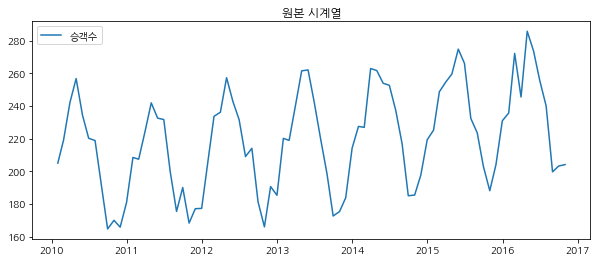

In [199]:
plt.figure(figsize=(10,4))
plt.plot(df['Passengers'], label='승객수')
plt.title('원본 시계열')
plt.legend()
plt.show()

12개월 단위로 계절성이 관측됨, 분산 증가는 없으므로 boxcox 변환 불필요  
점차적으로 증가하는 추세 발견됨

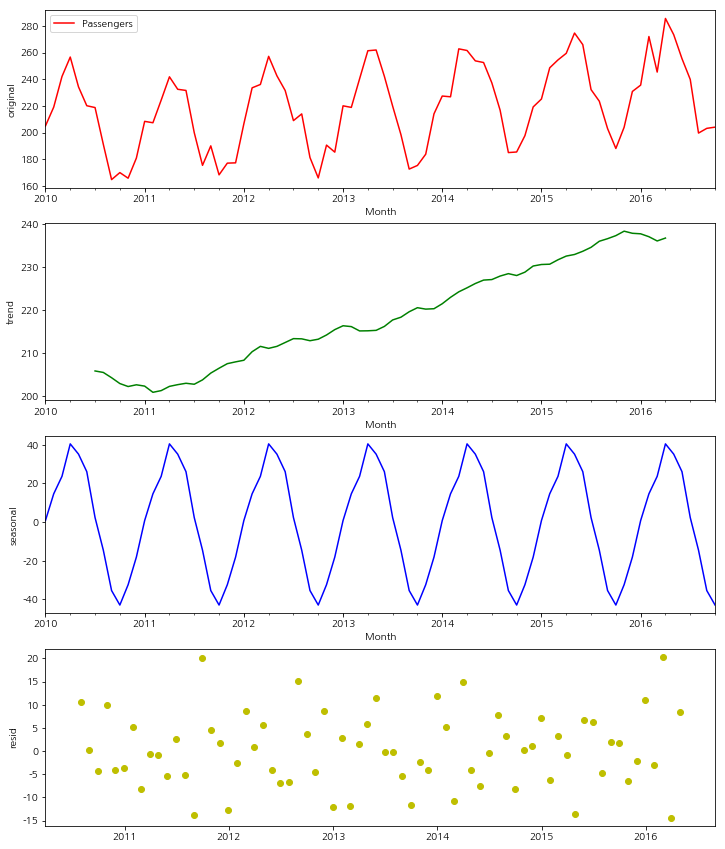

In [200]:
# 시계열 분해를 통해 추세, 계절성, 잔차 확인

from statsmodels.tsa.seasonal import seasonal_decompose

#seasonal(주기): 여기서는 년 주기(12개 데이터)로 확인(분기면 4)
fitted = seasonal_decompose(df, model='additive', period=12)
resid = fitted.resid #잔차
seasonal = fitted.seasonal #추정된 계절요소
trend = fitted.trend #추정된 트렌드 요소

title = ['original', 'trend', 'seasonal', 'resid']
dt_list = [df, trend, seasonal, resid]
co_list = ['r', 'g', 'b', 'y']

fig, ax = plt.subplots(4, 1, figsize=(12, 15))

for tt, data, ax, c in zip(title, dt_list, ax, co_list):
    if tt == 'resid':
        ax.scatter(x=data.index, y=data.values, color=c)
    else:
        data.plot(ax=ax, color=c)
    ax.set_ylabel(tt)
plt.show()

In [201]:
check_stationarity(df['Passengers'])

ADF 통계량: 0.2254, p-value: 0.9737
→ 정상성 없음, 차분 필요


In [202]:
s_diff = df['Passengers'].diff(12).dropna() #계절차분 먼저 수행
check_stationarity(s_diff)

ADF 통계량: -3.5346, p-value: 0.0071
→ 정상성 만족


계절차분만으로 정상성 만족

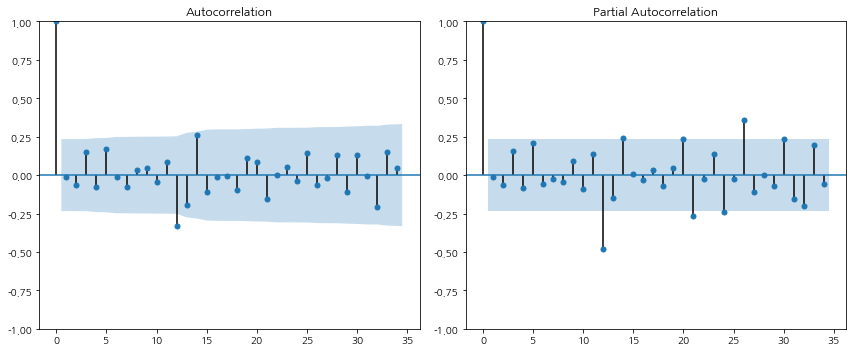

In [203]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plot_acf(s_diff, lags=34, ax=ax[0])
plot_pacf(s_diff, lags=34, ax=ax[1])
plt.tight_layout()
plt.show()

<계절성 차분>
- P: 2(lag 12, 24에서 피크)
- D:1
- Q: 1(lag 12에서 피크)
- S: 12

<일반차분>
- p: 0 (만약 lag 1~11에서 특별한 컷오프가 없다면 → p = 0)
- d: 0
- q: 0

In [165]:
from pmdarima import auto_arima
auto_arima(df, start_p=0, start_q=0, max_p=2, max_q=2, start_P=0, 
           start_Q=0, max_P=2, max_Q=2, m=12, D=1, seasonal=True, trace=False, 
           error_action='warn', suppress_warnings=True)

ARIMA(order=(0, 0, 0), scoring_args={}, seasonal_order=(2, 1, 0, 12),
      suppress_warnings=True)

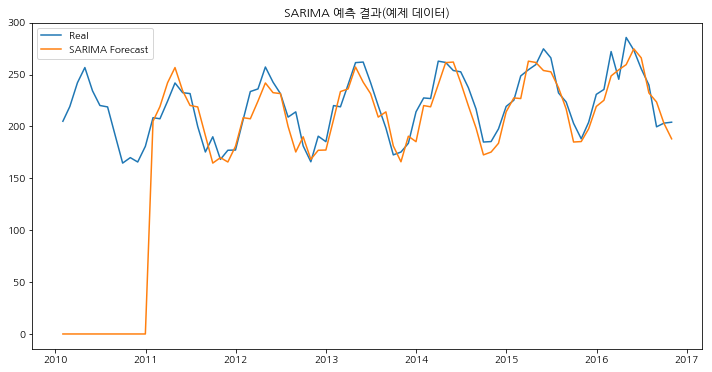

In [204]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

model = SARIMAX(df['Passengers'],
                order=(0, 0, 0),      # (p,d,q)
                seasonal_order=(0, 1, 0, 12))  # (P,D,Q,s)
result = model.fit()

# 예측 (전체 구간)
df['Forecast'] = result.predict(start=0, end=len(df)-1)

# 결과 시각화
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Passengers'], label='Real')
plt.plot(df.index, df['Forecast'], label='SARIMA Forecast')
plt.legend()
plt.title('SARIMA 예측 결과(예제 데이터)')
plt.show()

In [205]:
print(result.summary())

                                SARIMAX Results                                 
Dep. Variable:               Passengers   No. Observations:                   82
Model:             SARIMAX(0, 1, 0, 12)   Log Likelihood                -284.012
Date:                  Sun, 31 Aug 2025   AIC                            570.024
Time:                          20:58:05   BIC                            572.273
Sample:                      01-31-2010   HQIC                           570.918
                           - 10-31-2016                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       195.7303     36.898      5.305      0.000     123.411     268.050
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 0.47
Prob(Q):                       

모수추정결과: 오차의 잔차를 제외한 파라미터가 유의하지 않음


잔차진단: 정규성, 독립성, 등분산성 만족

- Ljung-Box: p-value  잔차에 자기상관 없음
- Jarque-Bera (JB): p-value 잔차가 정규분포를 따름
- Heteroskedasticity (H):  잔차의 분산이 일정

MAE: 40.007
RMSE: 80.562
MAPE: 19.119


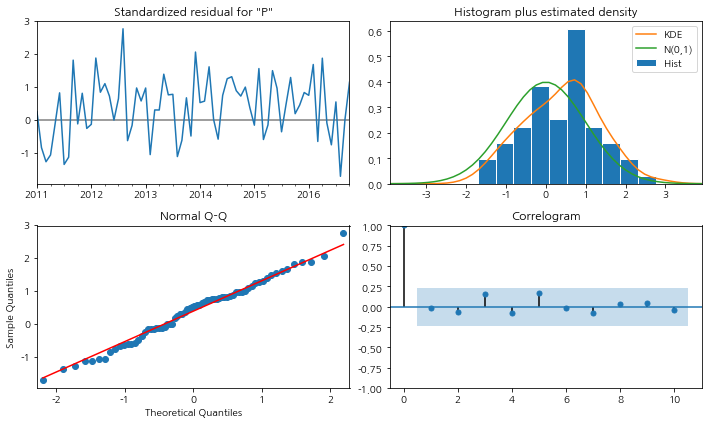

In [206]:
def MAPE(y_true, y_pred):
    mape = np.mean(np.abs((y_true - y_pred)/y_true))*100
    return mape

forecast = result.predict(start=0, end=len(df)-1)
MAE = mean_absolute_error(df['Passengers'], forecast)
rmse = np.sqrt(mean_squared_error(df['Passengers'], forecast))
mape = MAPE(df['Passengers'], forecast)
print(f"MAE: {MAE:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAPE: {mape:.3f}")
result.plot_diagnostics(figsize=(10, 6)) #잔차 그래프
plt.tight_layout()
plt.show()